In [20]:
# from google.colab import drive
# drive.mount('/content/drive')

In [21]:
#Load the data
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [22]:
df.shape

(119390, 32)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [24]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [25]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [26]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [27]:
df.drop(columns=['company'], inplace=True) # It has lots of missing values not direct related to our analysis

In [28]:
df['children'] = df['children'].fillna(0)

In [29]:
df['agent'] = df['agent'].fillna(0)

In [30]:
df.dropna(subset=['country'], inplace=True)

In [31]:
df.shape

(118902, 31)

In [32]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [33]:
# 1. Detect duplicates
df.duplicated().sum()
df[df.duplicated()].head(10)

# 2. Show repeat groups (evidence)
group_sizes = df.groupby(list(df.columns)).size().reset_index(name='count')
group_sizes = group_sizes[group_sizes['count'] > 1].sort_values('count', ascending=False)
group_sizes.head(10)

# 3. Now drop
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)

(86937, 31)


In [34]:
df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"])

In [35]:
df['reservation_status_date'].dtypes

dtype('<M8[ns]')

In [36]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937.000000,86937
mean,0.275958,80.195705,2016.211786,26.841149,15.817753,1.007442,2.628881,1.878590,0.139216,0.010835,0.039235,0.030229,0.176714,0.271864,81.112196,0.753523,106.573115,0.083451,0.699507,2016-08-31 15:20:46.626867712
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,12.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,72.250000,0.000000,0.000000,2016-03-19 00:00:00
50%,0.000000,50.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,98.400000,0.000000,0.000000,2016-09-08 00:00:00
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,0.000000,134.100000,0.000000,1.000000,2017-03-06 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.446999,86.100697,0.686041,13.654017,8.834629,1.028770,2.043750,0.625847,0.456793,0.113594,0.194155,0.369580,1.717914,0.728101,109.944861,10.041988,54.958089,0.280406,0.831839,NaN


In [37]:
df['adr'].min()

-6.38

In [38]:
df['adults'].max()

55

In [39]:
df['adults'].value_counts().sort_index(ascending=False).head(10)

,count
adults,
55,1
50,1
40,1
27,2
26,5
20,2
10,1
6,1
5,2


In [40]:
df = df[df['adults'] > 0]
df = df[df['adults'] <= 4]
df = df[df['adr'] > 0]

In [41]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [42]:
df.shape

(84930, 32)

In [43]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,61198
1,23732


In [68]:
counts = df['is_canceled'].value_counts()
print(counts)
cancellation_rate = df['is_canceled'].mean() * 100
print(f"Cancellation rate: {cancellation_rate:.2f}%")

is_canceled
0    61198
1    23732
Name: count, dtype: int64
Cancellation rate: 27.94%


**Insight 1**

Out of 86,937 bookings, 27.6% were cancelled — still a significant revenue risk for the hotel.

In [45]:
df['hotel'].unique()

array(['Resort Hotel', 'City Hotel'], dtype=object)

In [46]:
df.groupby('hotel')['is_canceled'].mean()

,is_canceled
hotel,
City Hotel,0.304378
Resort Hotel,0.239833


**Insight 2**

City Hotel has a significantly higher cancellation rate (30.4) compared to Resort Hotel (24.0%) — indicating City Hotel bookings are more prone to cancellation, possibly due to business travel flexibility or different booking patterns.

In [47]:
df.groupby('is_canceled')['lead_time'].mean()

,lead_time
is_canceled,
0,71.214942
1,105.900978


**Insight 3**

Cancelled bookings have an average lead time of 106 days, notably higher than the 71 days for non-cancelled bookings — indicating that bookings made further in advance are more likely to be cancelled, possibly because plans change over longer time horizons.

In [48]:
df.groupby('deposit_type')['is_canceled'].mean()

,is_canceled
deposit_type,
No Deposit,0.271215
Non Refund,0.946962
Refundable,0.242991


**Insight 4**

The 94.7% cancellation rate for Non Refund bookings is unusually high and doesn't match expected behavior, likely because the 'cancelled' label in this dataset also includes failed/incomplete bookings (like payment failures) rather than only genuine guest cancellations — so this number should be interpreted with caution.

In [49]:
df['deposit_type'].value_counts()

,count
deposit_type,
No Deposit,83786
Non Refund,1037
Refundable,107


In [50]:
df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False)

,is_canceled
market_segment,
Undefined,1.000000
Online TA,0.356071
Groups,0.278838
Aviation,0.198198
Offline TA/TO,0.149110
Direct,0.148451
Corporate,0.124589
Complementary,0.081967


**Insight 5**

Online TA bookings have the highest cancellation rate (35.6%) among major market segments, followed by Groups (27.9%); Direct (14.8%) and Corporate (12.5%) bookings show much lower cancellation rates — suggesting direct, personal bookings are more committed than online travel agency or group bookings. (Note: the "Undefined" segment was excluded due to having only 2 records.)

In [51]:
df['market_segment'].value_counts()

,count
market_segment,
Online TA,50987
Offline TA/TO,13594
Direct,11391
Groups,4716
Corporate,3957
Aviation,222
Complementary,61
Undefined,2


In [52]:
df.groupby('arrival_date_month')['is_canceled'].mean().sort_values(ascending=False)

,is_canceled
arrival_date_month,
August,0.326122
July,0.322082
April,0.308190
June,0.306805
May,0.295930
December,0.277915
March,0.247705
September,0.247229
October,0.240655


**Insight 6**

Cancellation rates are highest during peak travel months — August (32.6%), July (32.2%), and April (30.8%) — likely corresponding to summer holiday season bookings where plans change more often. Winter months (November and January) show the lowest cancellation rates (~21-23%), possibly due to more committed/planned trips.

In [53]:
df.groupby('customer_type')['is_canceled'].mean().sort_values(ascending=False)

,is_canceled
customer_type,
Transient,0.306148
Contract,0.164098
Transient-Party,0.154031
Group,0.073413


**Insight 7**

Transient (individual, non-group) customers have the highest cancellation rate (30.6%), while Group customer type has the lowest (7.3%) — interestingly opposite to the market_segment finding where 'Groups' segment had a relatively high cancellation rate, suggesting 'customer_type: Group' and 'market_segment: Groups' represent different booking categories and shouldn't be confused

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt


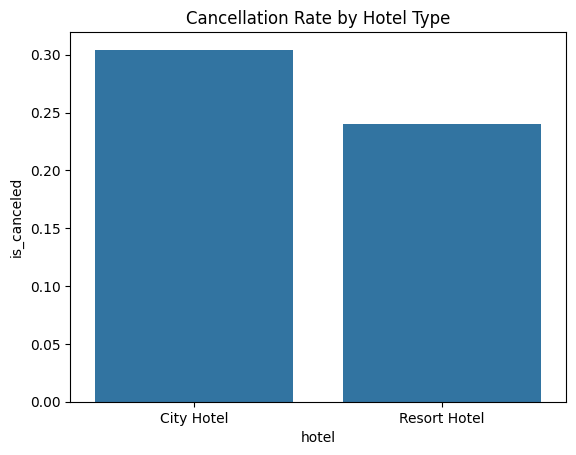

In [55]:
hotel_cancel = df.groupby('hotel')['is_canceled'].mean().reset_index()
sns.barplot(x='hotel', y='is_canceled', data=hotel_cancel)
plt.title('Cancellation Rate by Hotel Type')
plt.show()

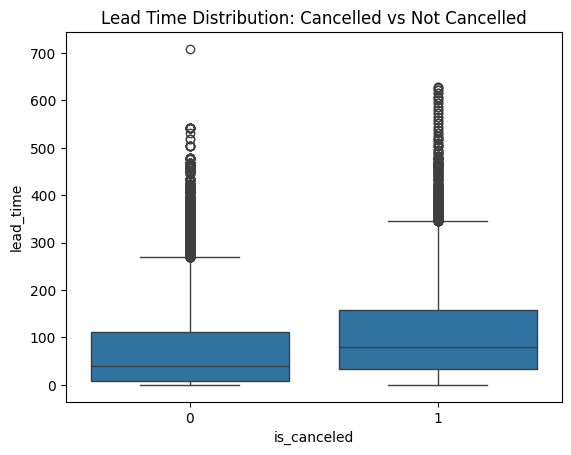

In [56]:
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead Time Distribution: Cancelled vs Not Cancelled')
plt.show()

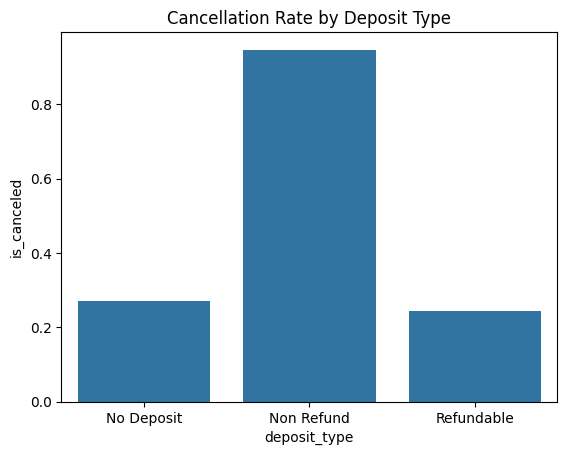

In [57]:
deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean().reset_index()
sns.barplot(x='deposit_type', y='is_canceled', data=deposit_cancel)
plt.title('Cancellation Rate by Deposit Type')
plt.show()

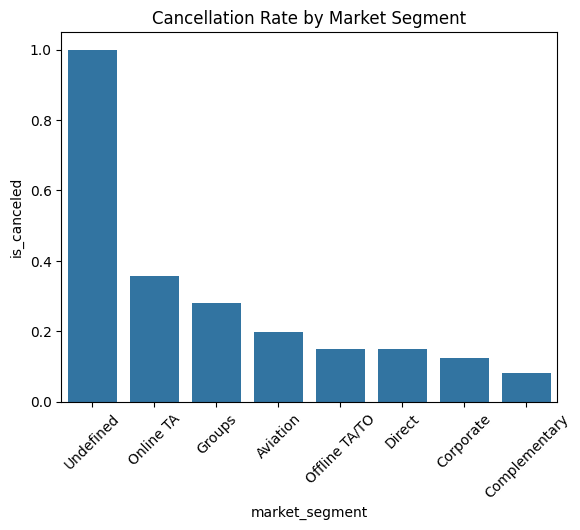

In [58]:
segment_cancel = df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='market_segment', y='is_canceled', data=segment_cancel)
plt.title('Cancellation Rate by Market Segment')
plt.xticks(rotation=45)
plt.show()

In [59]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
month_cancel = df.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order).reset_index()

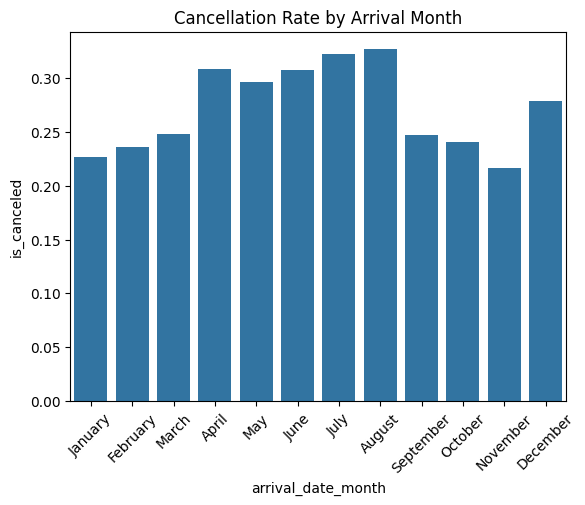

In [60]:
sns.barplot(x='arrival_date_month', y='is_canceled', data=month_cancel)
plt.title('Cancellation Rate by Arrival Month')
plt.xticks(rotation=45)
plt.show()

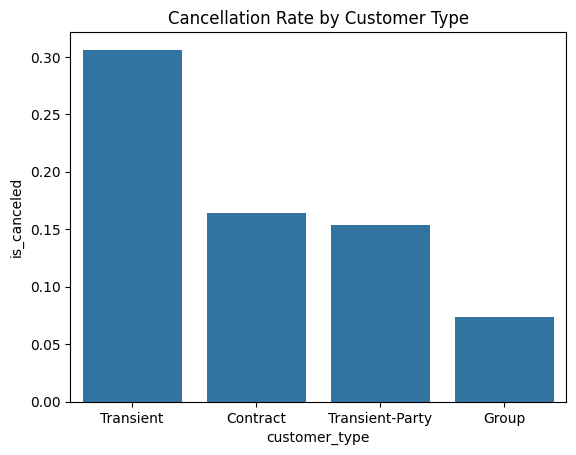

In [61]:
customer_cancel = df.groupby('customer_type')['is_canceled'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='customer_type', y='is_canceled', data=customer_cancel)
plt.title('Cancellation Rate by Customer Type')
plt.show()


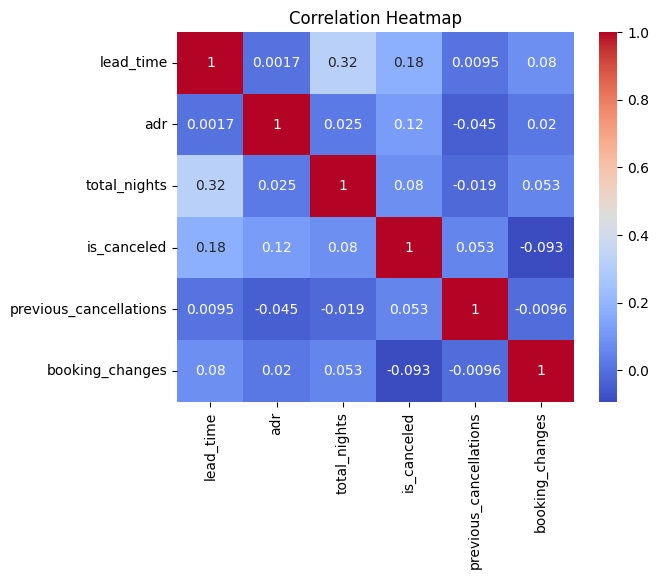

In [62]:
numeric_cols = ['lead_time', 'adr', 'total_nights', 'is_canceled', 'previous_cancellations', 'booking_changes']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Insight 8**

No single numerical variable shows a strong linear correlation with cancellation (is_canceled) — correlations with lead_time, previous_cancellations, etc. are weak. This suggests cancellation is driven more by categorical factors (deposit type, market segment, customer type, hotel type) and combinations of factors, rather than any single numerical predictor.

## Project Summary

### 1. Objective
To analyze hotel booking data and identify key factors driving cancellations, in order to help the hotel reduce cancellation rates.

### 2. Dataset
116,715 bookings across 32 columns, covering hotel type, lead time, deposit type, market segment, customer type, and arrival dates.

### 3. Key Insights
1. Overall cancellation rate is 27.6% — still a significant portion of bookings.
2. City Hotel has a higher cancellation rate (30.4%) than Resort Hotel (24.0%).
3. Cancelled bookings have an average lead time of 106 days vs 71 days for non-cancelled — longer lead time means higher cancellation risk.
4. Non Refund deposit bookings show a 94.7% cancellation rate — unusually high, likely reflects payment failures/no-shows rather than true cancellations (data quality flag).
5. Online TA has the highest cancellation rate among major market segments (35.6%), followed by Groups (27.9%); Direct bookings have the lowest (14.8%). ("Undefined" segment excluded — only 2 records.)
6. Peak season months (August, July, April) show higher cancellation rates than winter months (November, January).
7. Transient (individual) customers cancel more (30.6%) than Group customer type (7.3%) — note this is the opposite direction from the market_segment "Groups" finding, since customer_type and market_segment categorize bookings differently.
8. No single numerical variable strongly correlates with cancellation — categorical factors (deposit type, segment, customer type) matter more than numerical ones.

### 4. Recommendations
- **Lead Time**: Send confirmation reminders or require reconfirmation for bookings made far in advance, since longer lead times correlate with higher cancellations.
- **Deposit Type**: Encourage refundable or partial-deposit policies for high-risk segments. The Non Refund spike likely reflects payment/no-show issues rather than genuine cancellations and should be investigated separately.
- **Market Segment**: Incentivize Direct bookings (discounts, loyalty perks) since they show the lowest cancellation rates. Apply stricter cancellation policies for Group and Online TA bookings.

In [66]:
df.to_csv('hotel_bookings_cleaned(1).csv', index=False)

In [67]:
from google.colab import files
files.download('hotel_bookings_cleaned(1).csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>